In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
PALETTE = sns.color_palette("Set2", 9)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold"
})


In [2]:
df_raw = pd.read_csv("data/processed_esg_financial_data.csv")

print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()


Shape: (11000, 16)

Columns: ['company_id', 'company_name', 'industry', 'region', 'year', 'revenue', 'profit_margin', 'market_cap', 'growth_rate', 'esg_overall', 'esg_environmental', 'esg_social', 'esg_governance', 'carbon_emissions', 'water_usage', 'energy_consumption']


,company_id,company_name,industry,region,year,revenue,profit_margin,market_cap,growth_rate,esg_overall,esg_environmental,esg_social,esg_governance,carbon_emissions,water_usage,energy_consumption
0,1,Company_1,Retail,Latin America,2015,0.002342,0.371429,0.000388,0.552703,0.548108,0.607,0.335,0.768,0.000193,0.000321,0.000038
1,1,Company_1,Retail,Latin America,2016,0.002422,0.351429,0.000422,0.529730,0.544865,0.589,0.328,0.785,0.000203,0.000338,0.000040
2,1,Company_1,Retail,Latin America,2017,0.002926,0.360000,0.000360,0.745946,0.542703,0.576,0.340,0.778,0.000247,0.000411,0.000049
3,1,Company_1,Retail,Latin America,2018,0.002890,0.347143,0.000325,0.471622,0.558919,0.623,0.334,0.783,0.000233,0.000389,0.000046
4,1,Company_1,Retail,Latin America,2019,0.002869,0.355714,0.000620,0.477027,0.543784,0.637,0.300,0.761,0.000228,0.000381,0.000045


In [3]:
df_raw.columns.tolist()

['company_id',
 'company_name',
 'industry',
 'region',
 'year',
 'revenue',
 'profit_margin',
 'market_cap',
 'growth_rate',
 'esg_overall',
 'esg_environmental',
 'esg_social',
 'esg_governance',
 'carbon_emissions',
 'water_usage',
 'energy_consumption']

In [4]:
# Keep numeric + categorical columns needed for analysis
cols_needed = [
    'company_name', 'industry', 'region', 'year',
    'revenue', 'profit_margin', 'market_cap', 'growth_rate',
    'esg_overall', 'esg_environmental', 'esg_social', 'esg_governance',
    'carbon_emissions', 'water_usage', 'energy_consumption'
]

df = df_raw[cols_needed].dropna()
print("Working shape:", df.shape)


Working shape: (11000, 15)


In [5]:
esg_cols = ['esg_environmental', 'esg_social', 'esg_governance']

# Create ESG category directly from overall score (cleaner + realistic)
df['ESG_Category'] = pd.qcut(df['esg_overall'], 3, labels=['Low', 'Medium', 'High'])

In [6]:
kpis = {
    "Avg Revenue":       df['revenue'].mean(),
    "Avg Profit Margin": df['profit_margin'].mean(),
    "Avg Growth Rate":   df['growth_rate'].mean(),
    "Avg Market Cap":    df['market_cap'].mean()
}

for k, v in kpis.items():
    print(f"{k}: {v:,.4f}")


Avg Revenue: 0.0256
Avg Profit Margin: 0.4414
Avg Growth Rate: 0.5518
Avg Market Cap: 0.0155


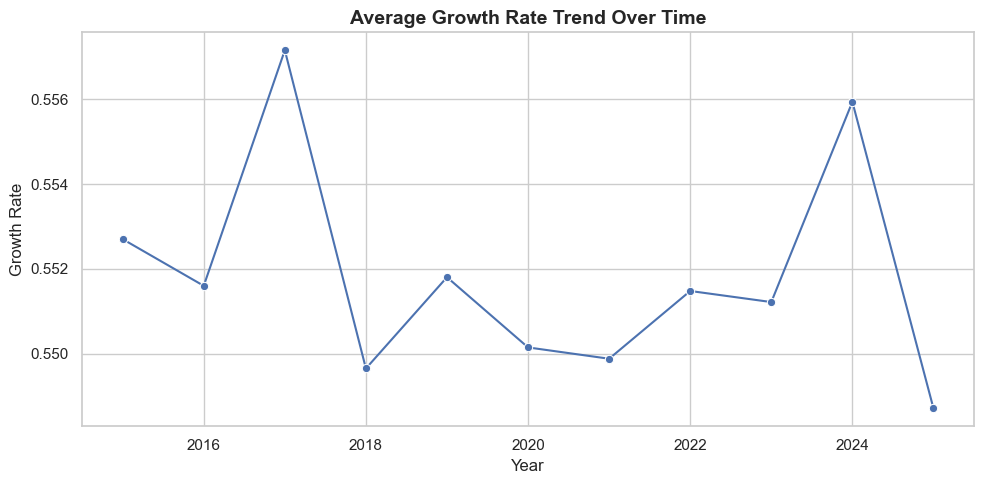

In [7]:
# Growth rate trend over time
growth_trend = df.groupby('year')['growth_rate'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=growth_trend, x='year', y='growth_rate', marker='o')
plt.title("Average Growth Rate Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Growth Rate")
plt.tight_layout()
plt.show()

## 📊 Section A – Dataset Overview

### A1 · Company Count by Industry

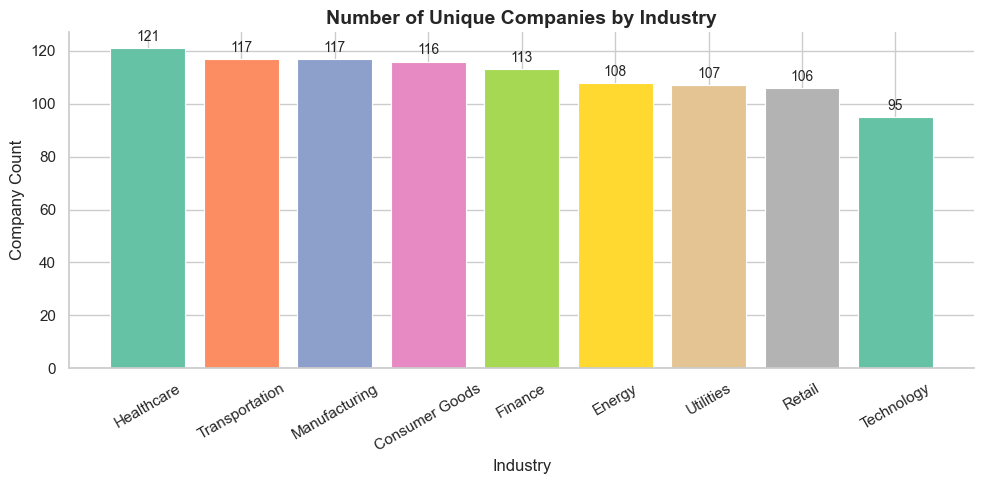

In [8]:
industry_counts = (df.groupby('industry')['company_name']
                         .nunique()
                         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(industry_counts.index, industry_counts.values,
              color=PALETTE, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("Number of Unique Companies by Industry")
ax.set_xlabel("Industry")
ax.set_ylabel("Company Count")
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.show()


### A2 · Data Distribution by Region

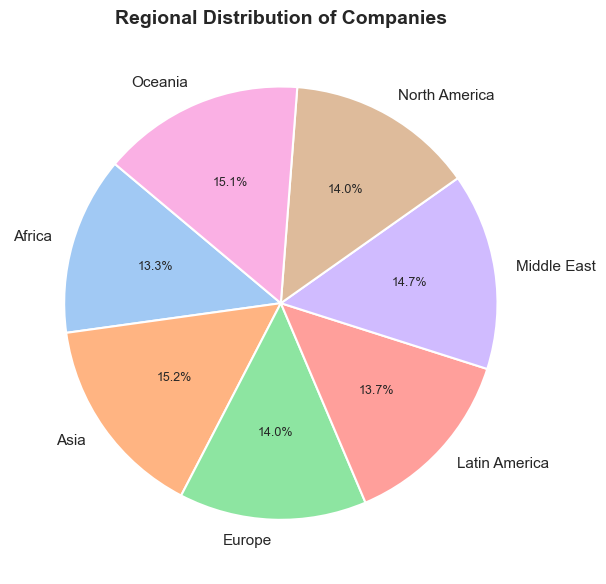

In [9]:
region_counts = df.groupby('region')['company_name'].nunique()

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("pastel", len(region_counts)),
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Regional Distribution of Companies")
plt.tight_layout()
plt.show()


### A4 · Average ESG Score Trend Over Years

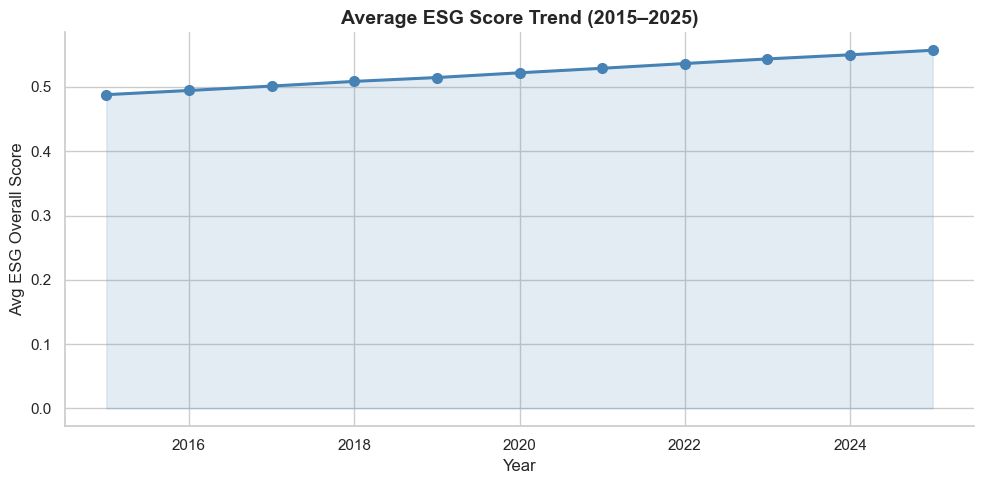

In [10]:
yearly_esg = df_raw.groupby('year')['esg_overall'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_esg['year'], yearly_esg['esg_overall'],
        marker='o', linewidth=2.2, color='steelblue', markersize=7)
ax.fill_between(yearly_esg['year'], yearly_esg['esg_overall'],
                alpha=0.15, color='steelblue')
ax.set_title("Average ESG Score Trend (2015–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Avg ESG Overall Score")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()
plt.tight_layout()
plt.show()


## 💼 Section B – Business Question Analysis

### BUSINESS QUESTION – 1
**Q1: Do companies with higher ESG scores perform better financially?**

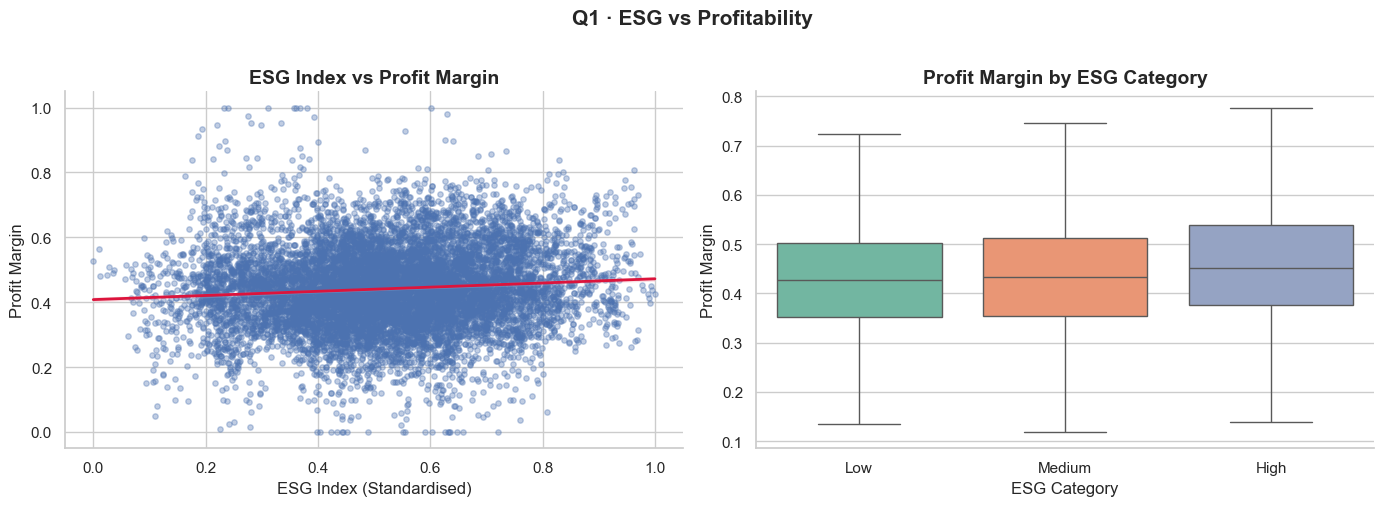

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter + regression
sns.regplot(
    x='esg_overall', y='profit_margin', data=df,
    scatter_kws={'alpha': 0.35, 's': 15},
    line_kws={'color': 'crimson', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title("ESG Index vs Profit Margin")
axes[0].set_xlabel("ESG Index (Standardised)")
axes[0].set_ylabel("Profit Margin")

# Boxplot: profitability by ESG category
sns.boxplot(
    x='ESG_Category', y='profit_margin', data=df,
    palette='Set2', order=['Low', 'Medium', 'High'],
    ax=axes[1], showfliers=False
)
axes[1].set_title("Profit Margin by ESG Category")
axes[1].set_xlabel("ESG Category")
axes[1].set_ylabel("Profit Margin")

sns.despine()
plt.suptitle("Q1 · ESG vs Profitability", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### BUSINESS QUESTION – 2
**Q2: Is there a measurable relationship between ESG and revenue growth or profitability?**

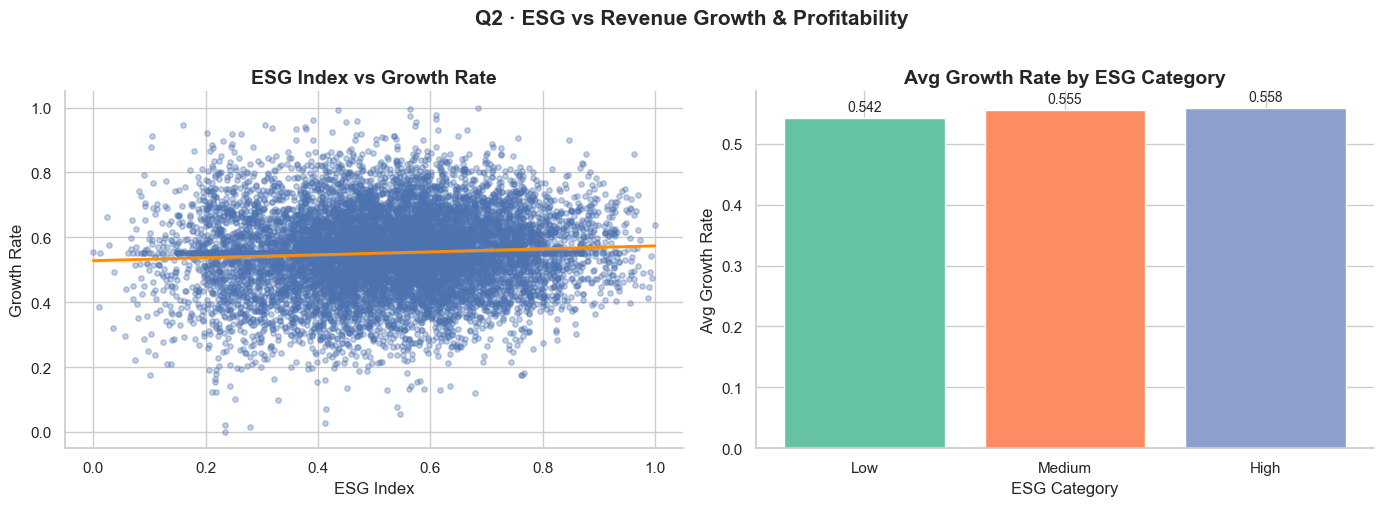

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    x='esg_overall', y='growth_rate', data=df,
    scatter_kws={'alpha': 0.35, 's': 15},
    line_kws={'color': 'darkorange', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title("ESG Index vs Growth Rate")
axes[0].set_xlabel("ESG Index")
axes[0].set_ylabel("Growth Rate")

# Mean growth rate per ESG category (bar)
mean_growth = (df.groupby('ESG_Category', observed=True)['growth_rate']
                 .mean()
                 .reindex(['Low', 'Medium', 'High']))
bars = axes[1].bar(mean_growth.index, mean_growth.values,
                   color=sns.color_palette('Set2', 3), edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
axes[1].set_title("Avg Growth Rate by ESG Category")
axes[1].set_xlabel("ESG Category")
axes[1].set_ylabel("Avg Growth Rate")

sns.despine()
plt.suptitle("Q2 · ESG vs Revenue Growth & Profitability", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### BUSINESS QUESTION – 3
**Q3: Which ESG pillar (Environmental / Social / Governance) has the most significant impact on financial performance?**

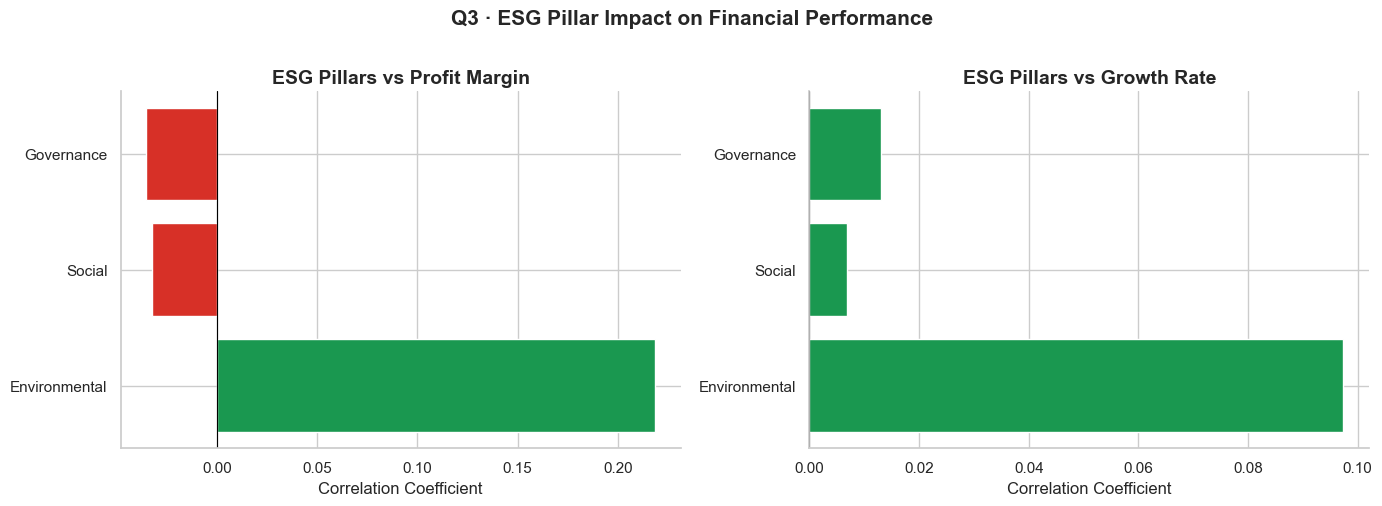

In [13]:
impact_df = df[['esg_environmental', 'esg_social', 'esg_governance',
                'profit_margin', 'growth_rate', 'revenue']].copy()

corr_pm = impact_df.corr()['profit_margin'].drop('profit_margin').drop(['growth_rate', 'revenue'])
corr_gr = impact_df.corr()['growth_rate'].drop('growth_rate').drop(['profit_margin', 'revenue'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pm = ['#d73027' if v < 0 else '#1a9850' for v in corr_pm.values]
axes[0].barh(corr_pm.index.str.replace('esg_', '').str.title(),
             corr_pm.values, color=colors_pm, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title("ESG Pillars vs Profit Margin")
axes[0].set_xlabel("Correlation Coefficient")

colors_gr = ['#d73027' if v < 0 else '#1a9850' for v in corr_gr.values]
axes[1].barh(corr_gr.index.str.replace('esg_', '').str.title(),
             corr_gr.values, color=colors_gr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("ESG Pillars vs Growth Rate")
axes[1].set_xlabel("Correlation Coefficient")

sns.despine()
plt.suptitle("Q3 · ESG Pillar Impact on Financial Performance", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### BUSINESS QUESTION – 4
**Q4: How does social responsibility influence company performance?**

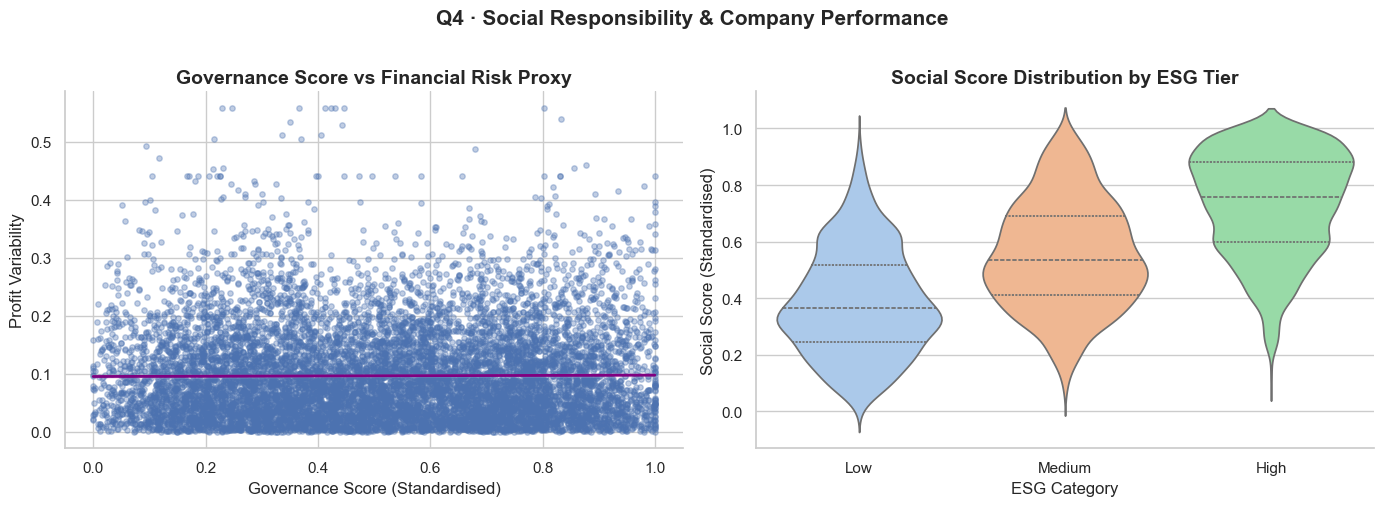

In [14]:
df['profit_risk_proxy'] = abs(df['profit_margin'] - df['profit_margin'].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: governance vs risk proxy
sns.regplot(
    x='esg_governance', y='profit_risk_proxy', data=df,
    scatter_kws={'alpha': 0.35, 's': 15},
    line_kws={'color': 'purple', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title("Governance Score vs Financial Risk Proxy")
axes[0].set_xlabel("Governance Score (Standardised)")
axes[0].set_ylabel("Profit Variability")

# NEW: Social score vs growth_rate strip/violin
sns.violinplot(
    x='ESG_Category', y='esg_social', data=df,
    palette='pastel', order=['Low', 'Medium', 'High'],
    inner='quartile', ax=axes[1]
)
axes[1].set_title("Social Score Distribution by ESG Tier")
axes[1].set_xlabel("ESG Category")
axes[1].set_ylabel("Social Score (Standardised)")

sns.despine()
plt.suptitle("Q4 · Social Responsibility & Company Performance", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### BUSINESS QUESTION – 5
**Q5: Is there a correlation between ESG scores and market valuation?**

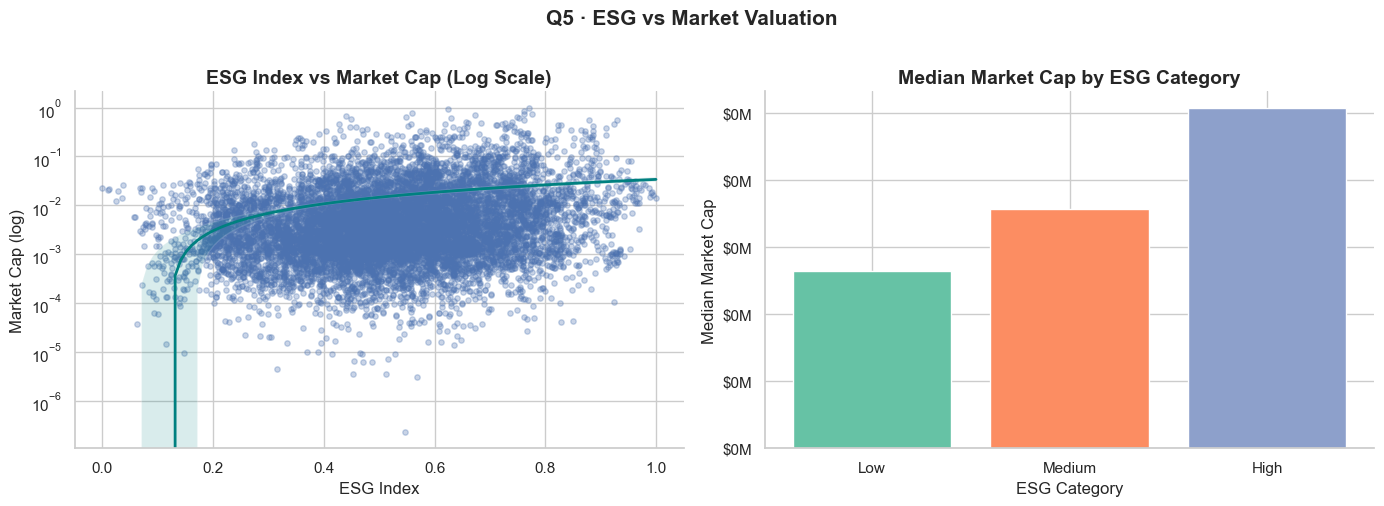

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    x='esg_overall', y='market_cap', data=df,
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'teal', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title("ESG Index vs Market Cap (Log Scale)")
axes[0].set_xlabel("ESG Index")
axes[0].set_ylabel("Market Cap (log)")

# Median market cap per ESG category
med_mc = (df.groupby('ESG_Category', observed=True)['market_cap']
            .median().reindex(['Low', 'Medium', 'High']))
axes[1].bar(med_mc.index, med_mc.values,
            color=sns.color_palette('Set2', 3), edgecolor='white')
axes[1].set_title("Median Market Cap by ESG Category")
axes[1].set_xlabel("ESG Category")
axes[1].set_ylabel("Median Market Cap")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e6:.0f}M' if x < 1e9 else f'${x/1e9:.1f}B'))

sns.despine()
plt.suptitle("Q5 · ESG vs Market Valuation", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Q5 (Extended) · Social Score vs Growth Rate

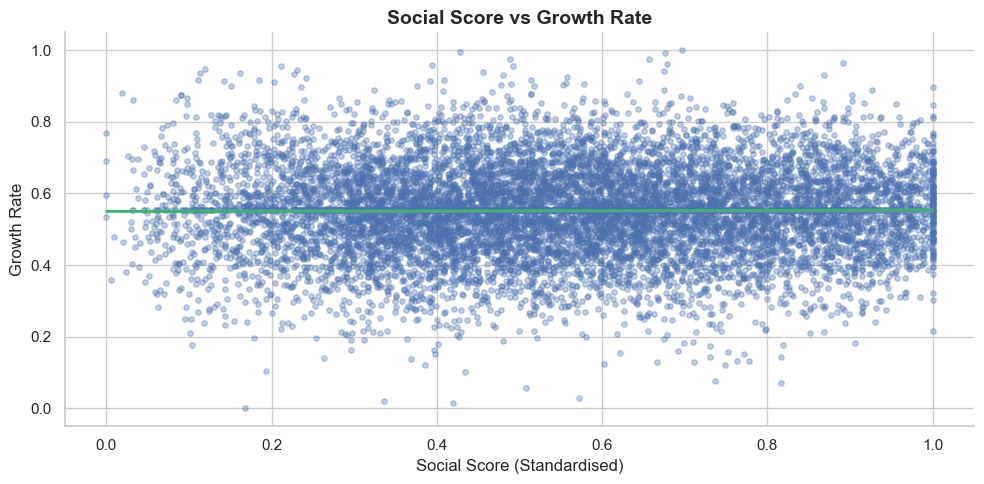

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(
    x='esg_social', y='growth_rate', data=df,
    scatter_kws={'alpha': 0.35, 's': 15},
    line_kws={'color': 'mediumseagreen', 'linewidth': 2},
    ax=ax
)
ax.set_title("Social Score vs Growth Rate")
ax.set_xlabel("Social Score (Standardised)")
ax.set_ylabel("Growth Rate")
sns.despine()
plt.tight_layout()
plt.show()


### Q6 · Environmental Score vs Profitability

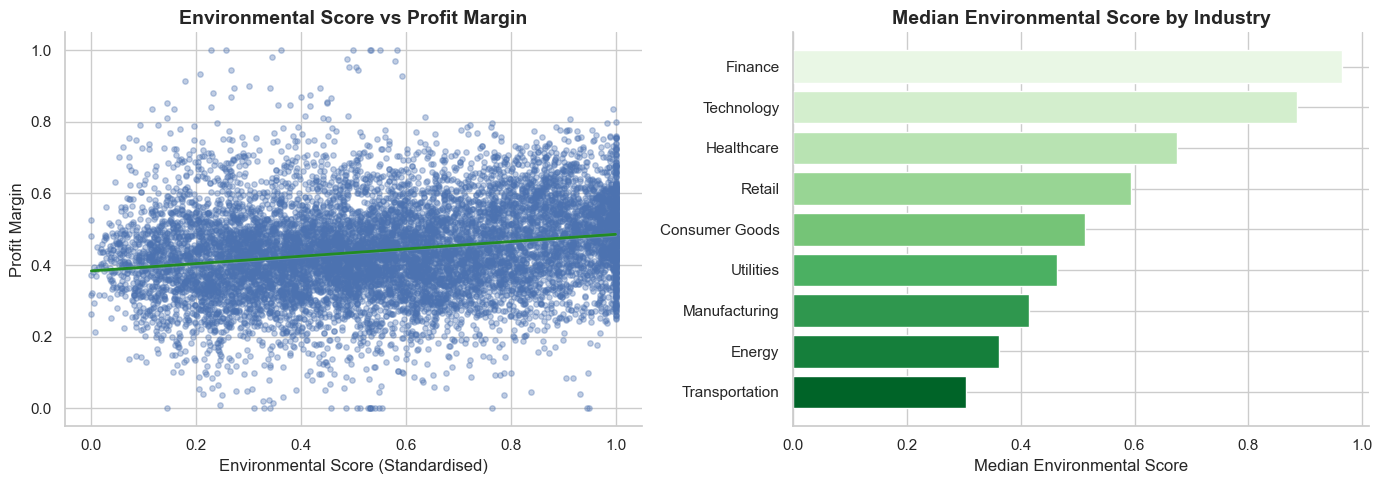

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    x='esg_environmental', y='profit_margin', data=df,
    scatter_kws={'alpha': 0.35, 's': 15},
    line_kws={'color': 'forestgreen', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title("Environmental Score vs Profit Margin")
axes[0].set_xlabel("Environmental Score (Standardised)")
axes[0].set_ylabel("Profit Margin")

# Environmental score across industries (box)
env_ind = df_raw.groupby('industry')['esg_environmental'].median().sort_values()
axes[1].barh(env_ind.index, env_ind.values,
             color=sns.color_palette('Greens_r', len(env_ind)), edgecolor='white')
axes[1].set_title("Median Environmental Score by Industry")
axes[1].set_xlabel("Median Environmental Score")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()


### BUSINESS QUESTION · Q7 – ESG vs Market Valuation (Log Scale)

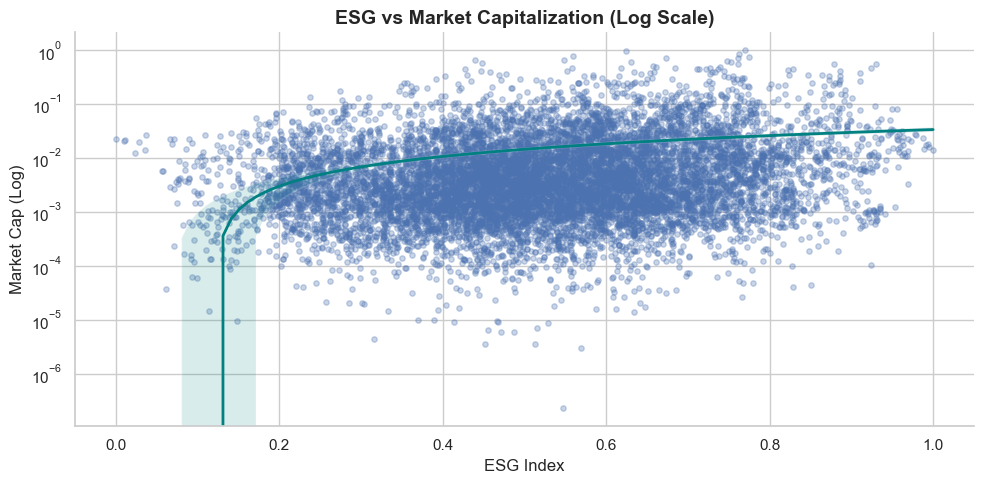

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(
    x='esg_overall', y='market_cap', data=df,
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'teal', 'linewidth': 2}, ax=ax
)
ax.set_yscale('log')
ax.set_title("ESG vs Market Capitalization (Log Scale)")
ax.set_xlabel("ESG Index")
ax.set_ylabel("Market Cap (Log)")
sns.despine()
plt.tight_layout()
plt.show()


### BUSINESS QUESTION · ESG Segmentation – Profitability Distribution

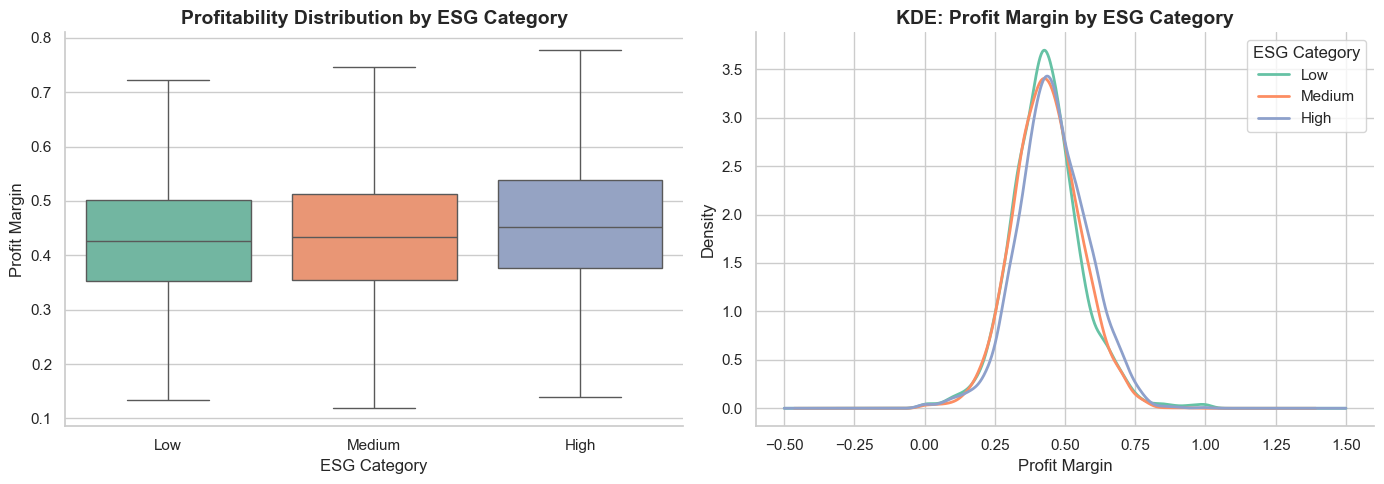

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original boxplot
sns.boxplot(
    x='ESG_Category', y='profit_margin', data=df,
    palette='Set2', order=['Low', 'Medium', 'High'],
    ax=axes[0], showfliers=False
)
axes[0].set_title("Profitability Distribution by ESG Category")
axes[0].set_xlabel("ESG Category")
axes[0].set_ylabel("Profit Margin")

# Additional: KDE of profit margin per ESG category
for cat, color in zip(['Low', 'Medium', 'High'],
                       sns.color_palette('Set2', 3)):
    subset = df[df['ESG_Category'] == cat]
    subset['profit_margin'].plot.kde(ax=axes[1], label=cat, color=color, linewidth=2)

axes[1].set_title("KDE: Profit Margin by ESG Category")
axes[1].set_xlabel("Profit Margin")
axes[1].set_ylabel("Density")
axes[1].legend(title='ESG Category')

sns.despine()
plt.tight_layout()
plt.show()


## 🔍 Section C – Additional Deep-Dive Visuals

### C2 · Average ESG Scores by Region (Grouped Bar)

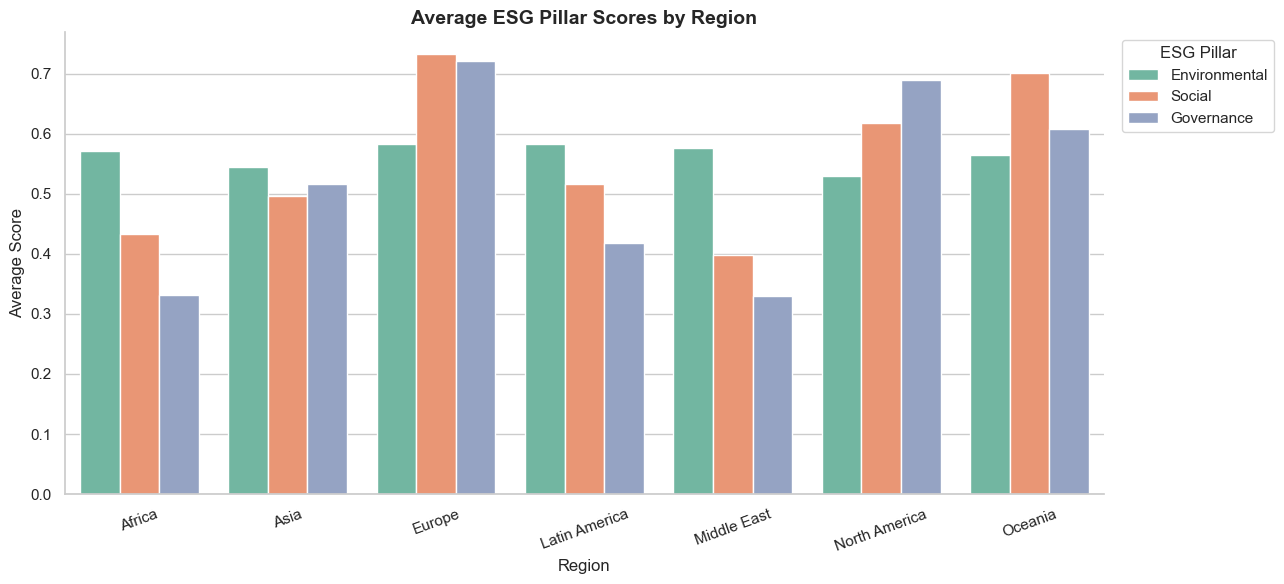

In [20]:
region_esg = (df_raw.groupby('region')[
    ['esg_environmental', 'esg_social', 'esg_governance']
].mean().rename(columns={
    'esg_environmental': 'Environmental',
    'esg_social': 'Social',
    'esg_governance': 'Governance'
}))

region_esg_melt = region_esg.reset_index().melt(
    id_vars='region', var_name='ESG Pillar', value_name='Avg Score'
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    x='region', y='Avg Score', hue='ESG Pillar',
    data=region_esg_melt, palette='Set2', ax=ax
)
ax.set_title("Average ESG Pillar Scores by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Average Score")
ax.tick_params(axis='x', rotation=20)
ax.legend(title='ESG Pillar', bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


### C3 · Carbon Emissions & Environmental Score by Industry

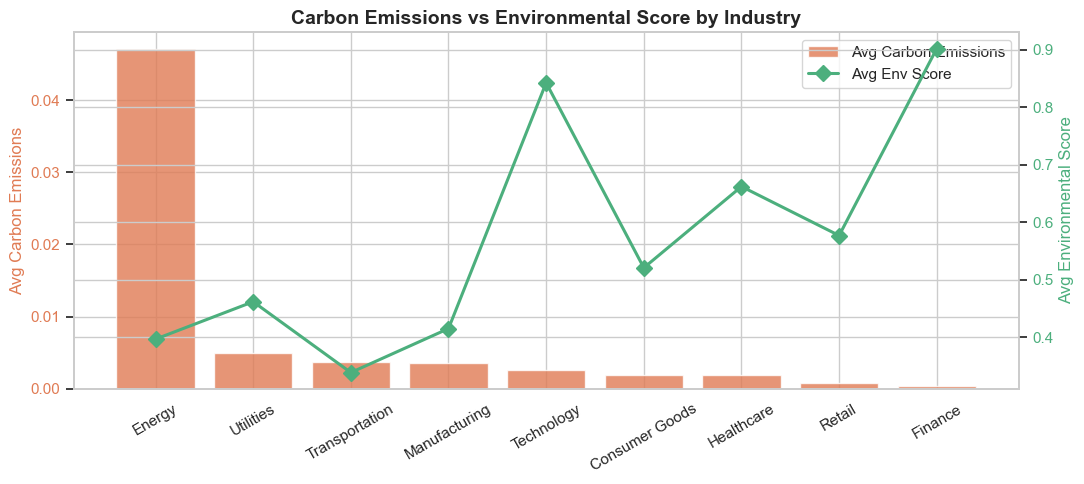

In [21]:
carbon_df = (df_raw.groupby('industry')
                .agg(avg_carbon=('carbon_emissions', 'mean'),
                     avg_env=('esg_environmental', 'mean'))
                .sort_values('avg_carbon', ascending=False))

fig, ax1 = plt.subplots(figsize=(11, 5))

color1 = '#e07b54'
color2 = '#4caf7d'

ax1.bar(carbon_df.index, carbon_df['avg_carbon'], color=color1,
        alpha=0.8, label='Avg Carbon Emissions', edgecolor='white')
ax1.set_ylabel("Avg Carbon Emissions", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=30)

ax2 = ax1.twinx()
ax2.plot(carbon_df.index, carbon_df['avg_env'],
         color=color2, marker='D', linewidth=2.2, markersize=8, label='Avg Env Score')
ax2.set_ylabel("Avg Environmental Score", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title("Carbon Emissions vs Environmental Score by Industry")
fig.tight_layout()
plt.show()


### C7 · ESG Category Distribution Across Regions (Stacked Bar)

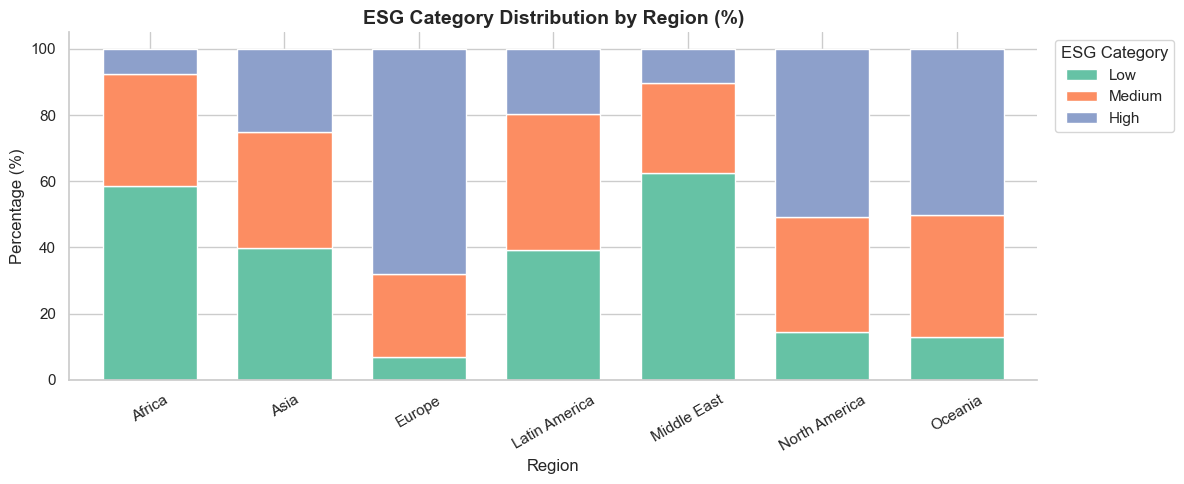

In [22]:
region_cat = (df.groupby(['region', 'ESG_Category'], observed=True)
                .size()
                .unstack(fill_value=0)[['Low', 'Medium', 'High']])

region_cat_pct = region_cat.div(region_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
region_cat_pct.plot(
    kind='bar', stacked=True,
    color=sns.color_palette('Set2', 3),
    ax=ax, edgecolor='white', width=0.7
)
ax.set_title("ESG Category Distribution by Region (%)")
ax.set_xlabel("Region")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=30)
ax.legend(title='ESG Category', bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


### C9 · Top 10 vs Bottom 10 Companies by ESG Index

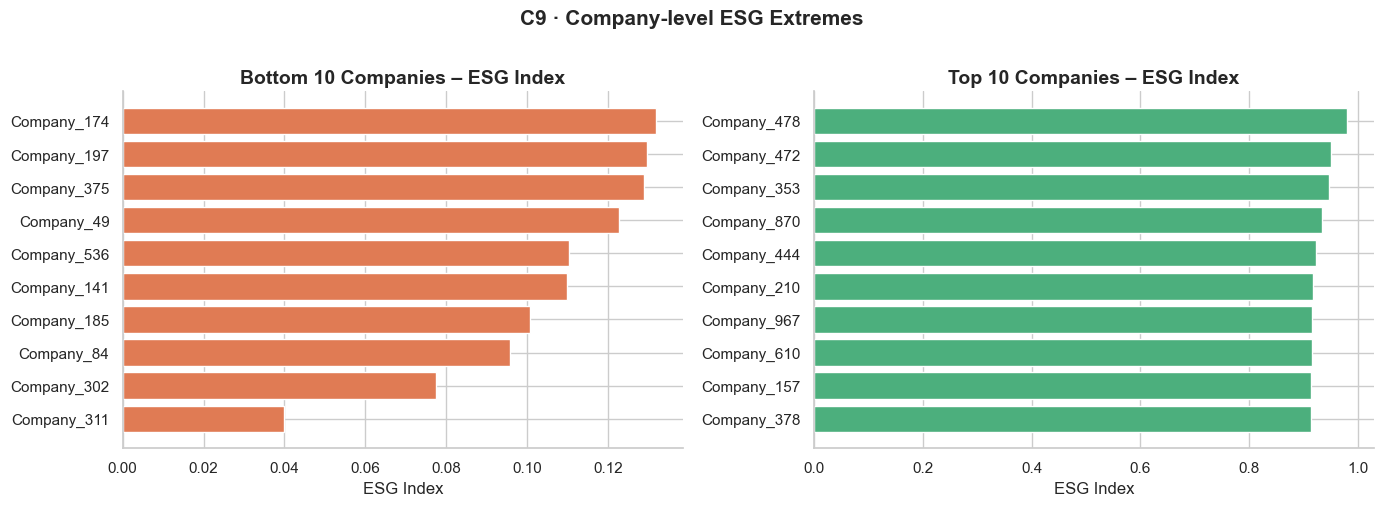

In [23]:
company_esg = (df.groupby('company_name')['esg_overall']
                 .mean()
                 .sort_values())

top10    = company_esg.tail(10)
bottom10 = company_esg.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(bottom10.index, bottom10.values,
             color='#e07b54', edgecolor='white')
axes[0].set_title("Bottom 10 Companies – ESG Index")
axes[0].set_xlabel("ESG Index")

axes[1].barh(top10.index, top10.values,
             color='#4caf7d', edgecolor='white')
axes[1].set_title("Top 10 Companies – ESG Index")
axes[1].set_xlabel("ESG Index")

sns.despine()
plt.suptitle("C9 · Company-level ESG Extremes", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### C10 · Market Cap vs Revenue (Bubble = ESG Index, Color = Industry)

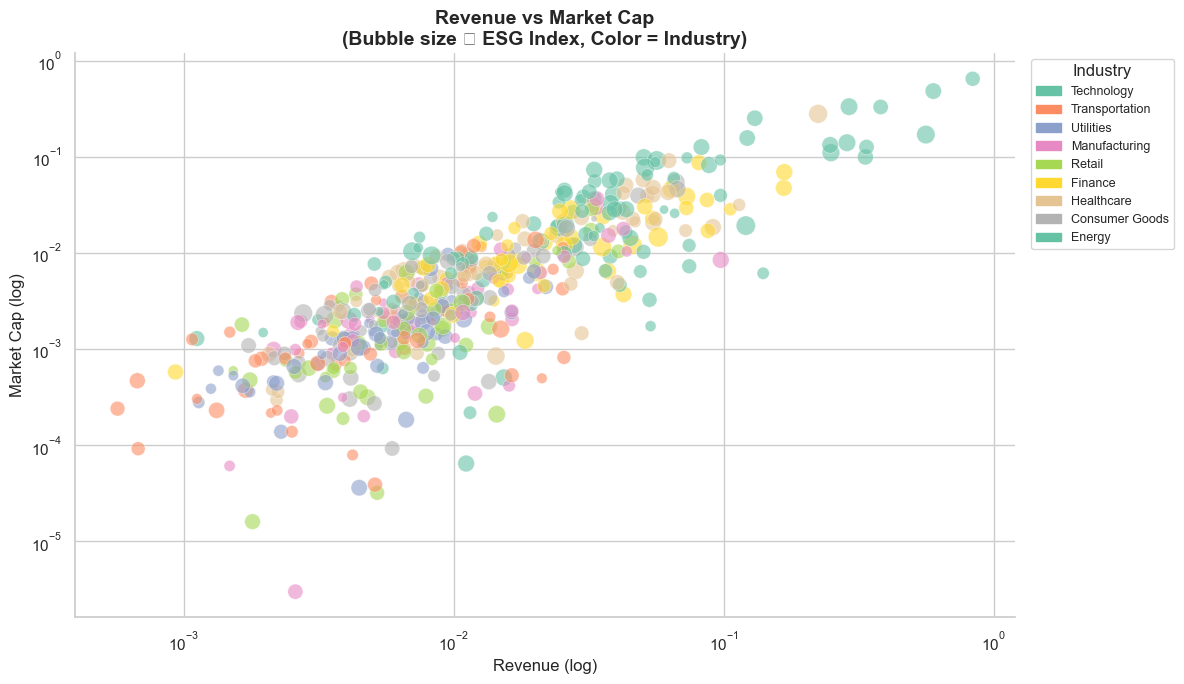

In [24]:
sample = df.sample(500, random_state=42)

industry_list = sample['industry'].unique()
color_map = {ind: PALETTE[i % len(PALETTE)] for i, ind in enumerate(industry_list)}
colors_ = sample['industry'].map(color_map)

sizes = (sample['esg_overall'] - sample['esg_overall'].min() + 0.1) * 200

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    sample['revenue'], sample['market_cap'],
    c=colors_, s=sizes, alpha=0.6, edgecolors='white', linewidths=0.4
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Revenue (log)")
ax.set_ylabel("Market Cap (log)")
ax.set_title("Revenue vs Market Cap\n(Bubble size ∝ ESG Index, Color = Industry)")

legend_patches = [mpatches.Patch(color=color_map[ind], label=ind)
                  for ind in industry_list]
ax.legend(handles=legend_patches, title='Industry',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


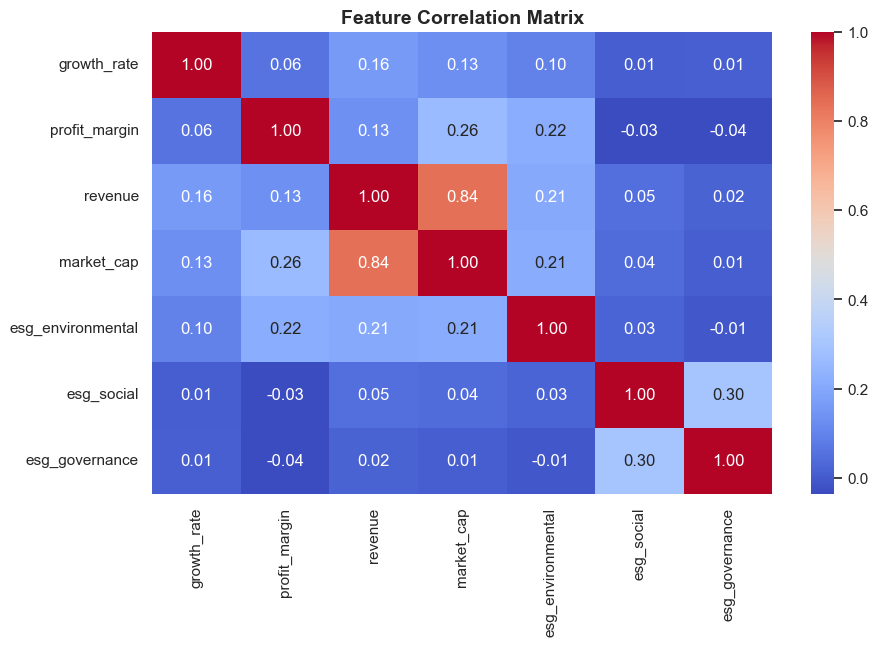

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[['growth_rate','profit_margin','revenue','market_cap',
        'esg_environmental','esg_social','esg_governance']].corr(),
    annot=True, cmap='coolwarm', fmt=".2f"
)
plt.title("Feature Correlation Matrix")
plt.show()